In [1]:
import os 
import sys
sys.path.append("../../")


import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.datasets import Mante, Mante_Teacher
from vi_rnn.saving import save_model, load_model

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params


%matplotlib inline

In [2]:
figures_dir = '../../figures'
cuda = False  # toggle if GPU is available
device = 'cpu'
neuromodulation = 'rank' # one of 'rank', 'presynaptic', 'postsynaptic', 'additive'
train_nm_params = True
train_batches = 4
teacher_rank = 60
student_rank = 1

### Set params for teacher network

In [5]:
train_teacher = True
model_params, training_params = get_default_params(n_rec=60)
training_params["n_epochs"] = 3000
model_params["n_inp"] = 2
training_params["l2_rates_reg"] = 0.1
model_params['rank']= teacher_rank
model_params['ds'] = 2
training_params["neuromodulation"] = "rank" # rank, postsynaptic, additive or presynaptic 
model_params["neuromodulation"] = "rank" # rank, postsynaptic, additive or presynaptic 
model_params["train_b_rec"] = False # don't train the neuron biases

data_dir = f"../../data/mante_{training_params['neuromodulation']}_rank_{model_params['rank']}/"
model_dir = "../../models/students/"

rnn_mante = RNN(model_params)

### Define Mante task

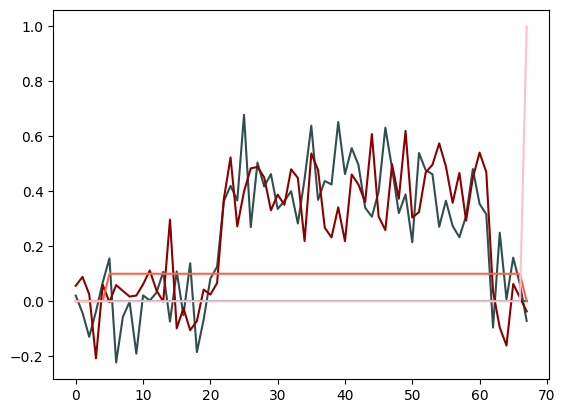

In [6]:
# Plot an example trial for teacher RNN

task_params_teacher = {
    "name": "mante",
    "fixation_dur":5,
    "stimulus_dur":40,
    "delay_dur":5,
    "response_dur":1,
    "std":.1,
    "scale":.1}
# rdm = RDM(task_params_teacher)
mante = Mante(task_params_teacher)
stimulus, targets, mask=mante.__getitem__(0)
plt.plot(stimulus[:,0], c='darkslategray')
plt.plot(stimulus[:,2], c='teal')
plt.plot(stimulus[:,1], c='darkred')
plt.plot(stimulus[:,3], c='tomato')

plt.plot(targets, c='pink')

### Train or load teacher network

In [7]:
# train or load teacher RNN
if train_teacher:
    losses, reg_losses = train_rnn(
        rnn_mante, training_params, mante, sync_wandb=False
    )
    save_rnn(
        data_dir + f"rnn_mante_{neuromodulation}_rank_{model_params['rank']}",
        rnn_mante,
        model_params,
        task_params_teacher,
        training_params,
    )
else:
    rnn_mante, model_params, task_params_teacher, training_params = load_rnn(
        data_dir + f"rnn_mante_{neuromodulation}_rank_{model_params['rank']}"
    )

using l2 rates reg
epoch 3000 / 3000: time=98.3 s, task loss=0.02569, reg loss=0.20427
Done. Training took 98.3 sec.


### Test teacher output

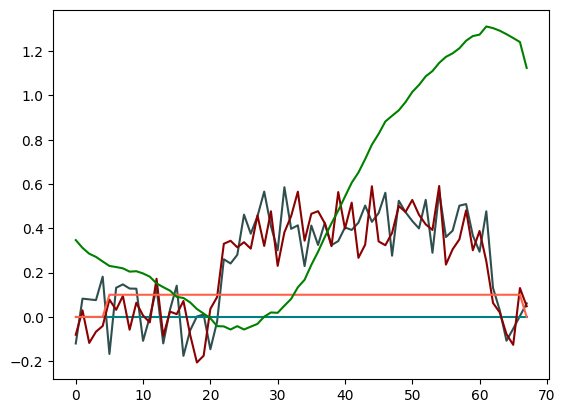

In [8]:
stimulus, targets, mask=mante.__getitem__(0)
plt.plot(stimulus[:,0], c='darkslategray')
plt.plot(stimulus[:,2], c='teal')
plt.plot(stimulus[:,1], c='darkred')
plt.plot(stimulus[:,3], c='tomato')

out = rnn_mante(stimulus[:, :2].unsqueeze(0), s=stimulus[:, 2:].unsqueeze(0))
plt.plot(out[1].view(68).detach().numpy(), c='green')

In [9]:
acc_list = np.zeros(10,)
for j in range(10):
    acc = 0.0
    for i in range(100):
        stimulus, targets, mask=mante.__getitem__(0)
        out = rnn_mante(stimulus[:, :2].unsqueeze(0), s=stimulus[:, 2:].unsqueeze(0))
        if np.sign(targets.mean()) == np.sign(out[1].detach().mean()):
            acc += 1
    acc_list[j] = acc

print(f'Teacher accuracy on task is {acc_list.mean()}% +- {acc_list.std()}')

Teacher accuracy on task is 94.7% +- 2.4919871588754225


Text(0.5, 1.0, 'Teacher Input weights')

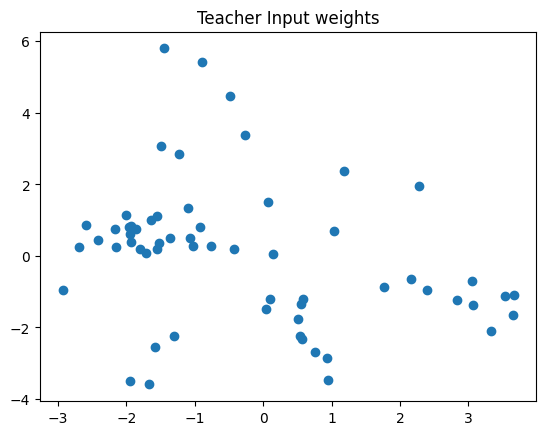

In [14]:
plt.scatter(rnn_mante.rnn.w_inp[0, :].detach().numpy(), rnn_mante.rnn.w_inp[1, :].detach().numpy())
plt.title('Teacher Input weights')  

### Generate teacher data

In [13]:
batch_size = 4
task_params = {
    "name": "mante",
    "n_neurons": rnn_mante.rnn.N,
    "out": "currents",
    "r0": 0,
    "R_x": 0.1,
    "R_z": 0.05,
    "n_trials": 400,
    "du": model_params["n_inp"],
    "dz": model_params["rank"],
    "neuromodulation": model_params["neuromodulation"]
}
# Extract weights
U, V, B = extract_orth_basis_rnn(rnn_mante)
I = rnn_mante.rnn.w_inp.detach()
A = rnn_mante.rnn.A.detach()
with torch.no_grad():
    task = Mante_Teacher(task_params, task_params_teacher, U, V, B, I, A, decay=0.9)

In [14]:
# Initialise VI / student setup
dim_z = student_rank
dim_N = model_params["n_rec"]
dim_x = model_params["n_rec"]
dim_u = model_params["n_inp"]
dim_s = model_params["ds"]

n_epochs = 400
wandb = True
# initialise encoder
enc_params = {"obs_grad": True, "init_scale": 0.1}

# initialise prior
prior_params = {
    "train_noise_x": True,
    "train_noise_z": True,
    "train_noise_z_t0": True,
    "init_noise_z": 0.05,
    "init_noise_z_t0": 1,
    "init_noise_x": 0.1,
    "scalar_noise_z": "Cov",
    "scalar_noise_x": False,
    "scalar_noise_z_t0": "Cov",
    "identity_readout": True,
    "activation": "relu",
    "exp_par": True,
    "shared_tau": 0.7,
    "readout_rates": task_params['out'],
    "train_obs_bias": False,
    "train_obs_weights": False,
    "train_latent_bias": False,
    "train_neuron_bias": True,
    "orth": False,
    "m_norm": False,
    "weight_dist": "uniform",
    "weight_scaler": 1,  # /dim_N,
    "initial_state": "trainable",
    "out_nonlinearity": "identity",
    "neuromodulation": model_params["neuromodulation"],
    "train_nm_params": train_nm_params
}

training_params = {
    "lr": 1e-3,
    "step_size": 6, 
    "gamma": 0.99,
    "lr_end": 1e-7,
    "opt_eps": 1e-8,
    "n_epochs": n_epochs,
    "grad_norm": 0,
    "bootstrap": False,
    "eval_epochs": 10,
    "batch_size": 10,
    "cuda": cuda,
    "smoothing": 20,
    "freq_cut_off": 10000,
    "sim_obs_noise": 0,
    "sim_latent_noise": 1,
    "k": 64, 
    "loss_f": "opt_VGTF",
    "resample": "systematic",  # , multinomial or none"
    "run_eval": False,
    "smooth_at_eval": False,
    "neuromodulation": neuromodulation,
    "sim_v": True
}

# initialise encoder
# enc_params = {
#     **enc_params,
#     "init_kernel_sizes": [21, 11, 1],
#     "nonlinearity": "gelu",
#     "n_channels": [64, 64],
#     "init_scale": 0.1,
#     "constant_var": False,
#     "n_hidden": 64,
#     "strides": [1, 1, 1],
#     "dilations": [1, 1, 1],
#     "padding": "same",
#     "padding_mode": "circular",
# }

VAE_params = {
    "dim_x": dim_x,
    "dim_z": dim_z,
    "dim_u": dim_u,
    "dim_N": dim_N,
    "dim_s": dim_s,
    "enc_architecture": "Inv_Obs",
    "enc_params": enc_params,
    "prior_architecture": "PLRNN",
    "prior_params": prior_params,
    "causal": True,
}


In [15]:
vae = VAE(VAE_params)

Neuromodulation type: rank
using ReLU activation
using uniform init
weight scaler 1


In [16]:
train_VAE(
    vae,
    training_params,
    task,
    eval_task=None,
    sync_wandb=wandb,
    out_dir=model_dir,
    fname=None,
    store_train_stats=False,
)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Training on : cpu


wandb: Currently logged in as: kaleab-belay (kaleab-belay-icm). Use `wandb login --relogin` to force relogin


Learning rate decay factor 0.9772372209558107
epoch 1 loss: 218.0335, ll: -218.0335, ll_x: 217.1519, ll_z: -1.7897 H: 2.6543, alpha: 0.84, lr: 0.001000, N_z: 0.0499, N_x: 0.1012
epoch 2 loss: 213.7008, ll: -213.7008, ll_x: 212.8170, ll_z: -1.7868 H: 2.6526, alpha: 0.84, lr: 0.001000, N_z: 0.0498, N_x: 0.1015
epoch 3 loss: 209.1420, ll: -209.1420, ll_x: 208.2559, ll_z: -1.7835 H: 2.6500, alpha: 0.84, lr: 0.001000, N_z: 0.0496, N_x: 0.1019
epoch 4 loss: 203.6057, ll: -203.6057, ll_x: 202.7164, ll_z: -1.7797 H: 2.6475, alpha: 0.84, lr: 0.001000, N_z: 0.0494, N_x: 0.1024
epoch 5 loss: 197.3514, ll: -197.3514, ll_x: 196.4577, ll_z: -1.7742 H: 2.6438, alpha: 0.83, lr: 0.001000, N_z: 0.0491, N_x: 0.1029
epoch 6 loss: 190.5302, ll: -190.5302, ll_x: 189.6304, ll_z: -1.7679 H: 2.6409, alpha: 0.83, lr: 0.001000, N_z: 0.0489, N_x: 0.1035
epoch 7 loss: 183.3936, ll: -183.3936, ll_x: 182.4874, ll_z: -1.7609 H: 2.6372, alpha: 0.83, lr: 0.000990, N_z: 0.0487, N_x: 0.1042
epoch 8 loss: 175.9897, ll: -1

[]

In [11]:
# load model 
model, vae_params, task_params, training_params = load_model(name=model_dir + "/../../models/students/mante_Inv_Obs_LRRNN_Z_Date_12024_11_04_T_22_37_47")

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: rank
using ReLU activation
using uniform init
weight scaler 1


c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\student_teacher\../..\vi_rnn\saving.py:125: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(state_dict

RuntimeError: Error(s) in loading state_dict for LRRNN:
	Missing key(s) in state_dict: "transition.A". 

In [ ]:
model = vae 
model.rnn.d_s = 1

### Get predictions for each trial/batch

In [17]:
X_pred = torch.zeros_like(task.data)
model = vae
model.eval()
for b in range(task.data.shape[0]):
    X_pred[b] = predict_X(
        model, 
        task.data.size(1),
        task.data[b].T,
        task.stim[b].T.unsqueeze(0),
        task.s[b].T.unsqueeze(0),
    ).reshape(dim_x, -1).T
    

eval_data shape: torch.Size([60, 68]). Upto trial: torch.Size([60, 68])
torch.Size([60, 1]) torch.Size([60, 68]) torch.Size([1, 60, 1, 1])
eval_data shape: torch.Size([60, 68]). Upto trial: torch.Size([60, 68])
torch.Size([60, 1]) torch.Size([60, 68]) torch.Size([1, 60, 1, 1])
eval_data shape: torch.Size([60, 68]). Upto trial: torch.Size([60, 68])
torch.Size([60, 1]) torch.Size([60, 68]) torch.Size([1, 60, 1, 1])
eval_data shape: torch.Size([60, 68]). Upto trial: torch.Size([60, 68])
torch.Size([60, 1]) torch.Size([60, 68]) torch.Size([1, 60, 1, 1])
eval_data shape: torch.Size([60, 68]). Upto trial: torch.Size([60, 68])
torch.Size([60, 1]) torch.Size([60, 68]) torch.Size([1, 60, 1, 1])
eval_data shape: torch.Size([60, 68]). Upto trial: torch.Size([60, 68])
torch.Size([60, 1]) torch.Size([60, 68]) torch.Size([1, 60, 1, 1])
eval_data shape: torch.Size([60, 68]). Upto trial: torch.Size([60, 68])
torch.Size([60, 1]) torch.Size([60, 68]) torch.Size([1, 60, 1, 1])
eval_data shape: torch.Size

#### Plot student neural activity vs teacher activity

n outliers: 0.0


C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_18396\1120670902.py:17: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')


n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0


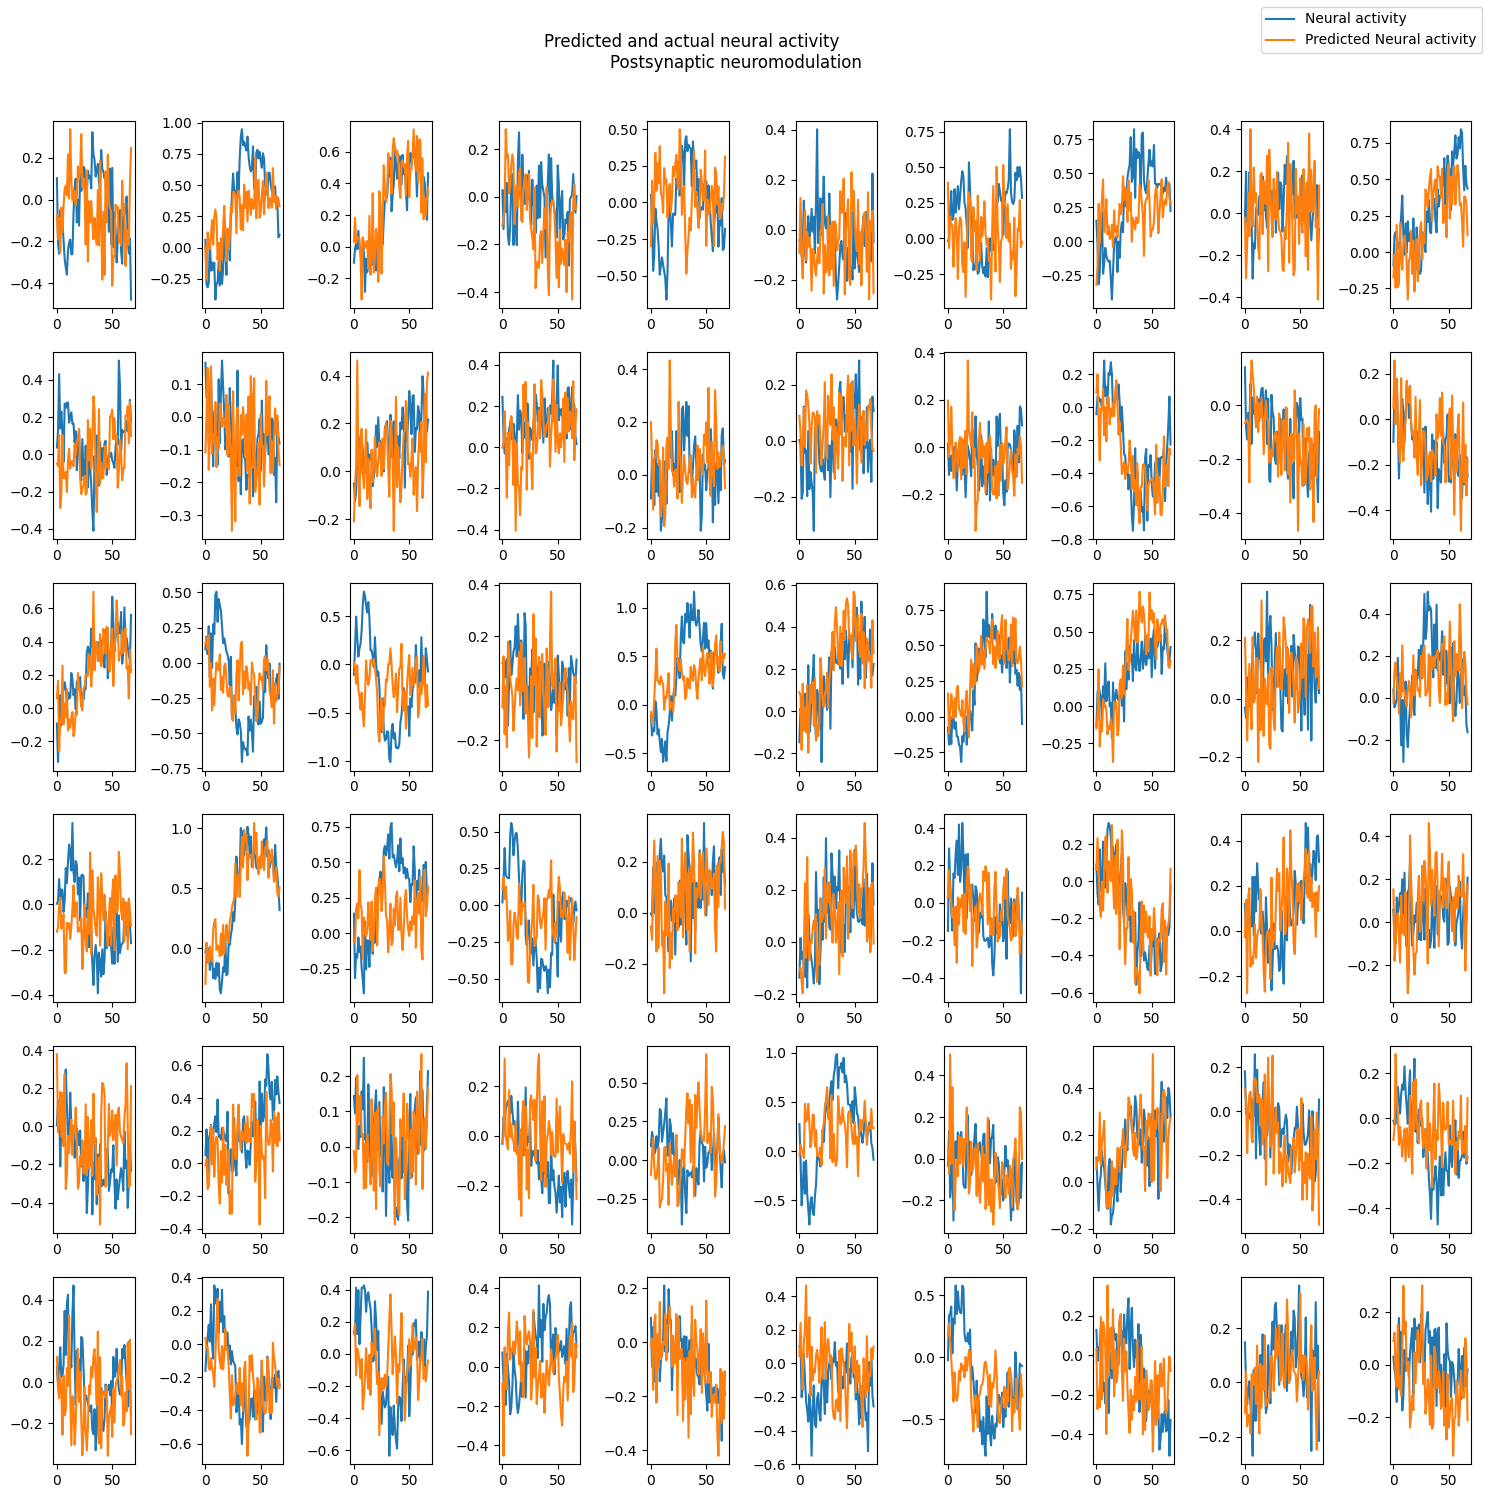

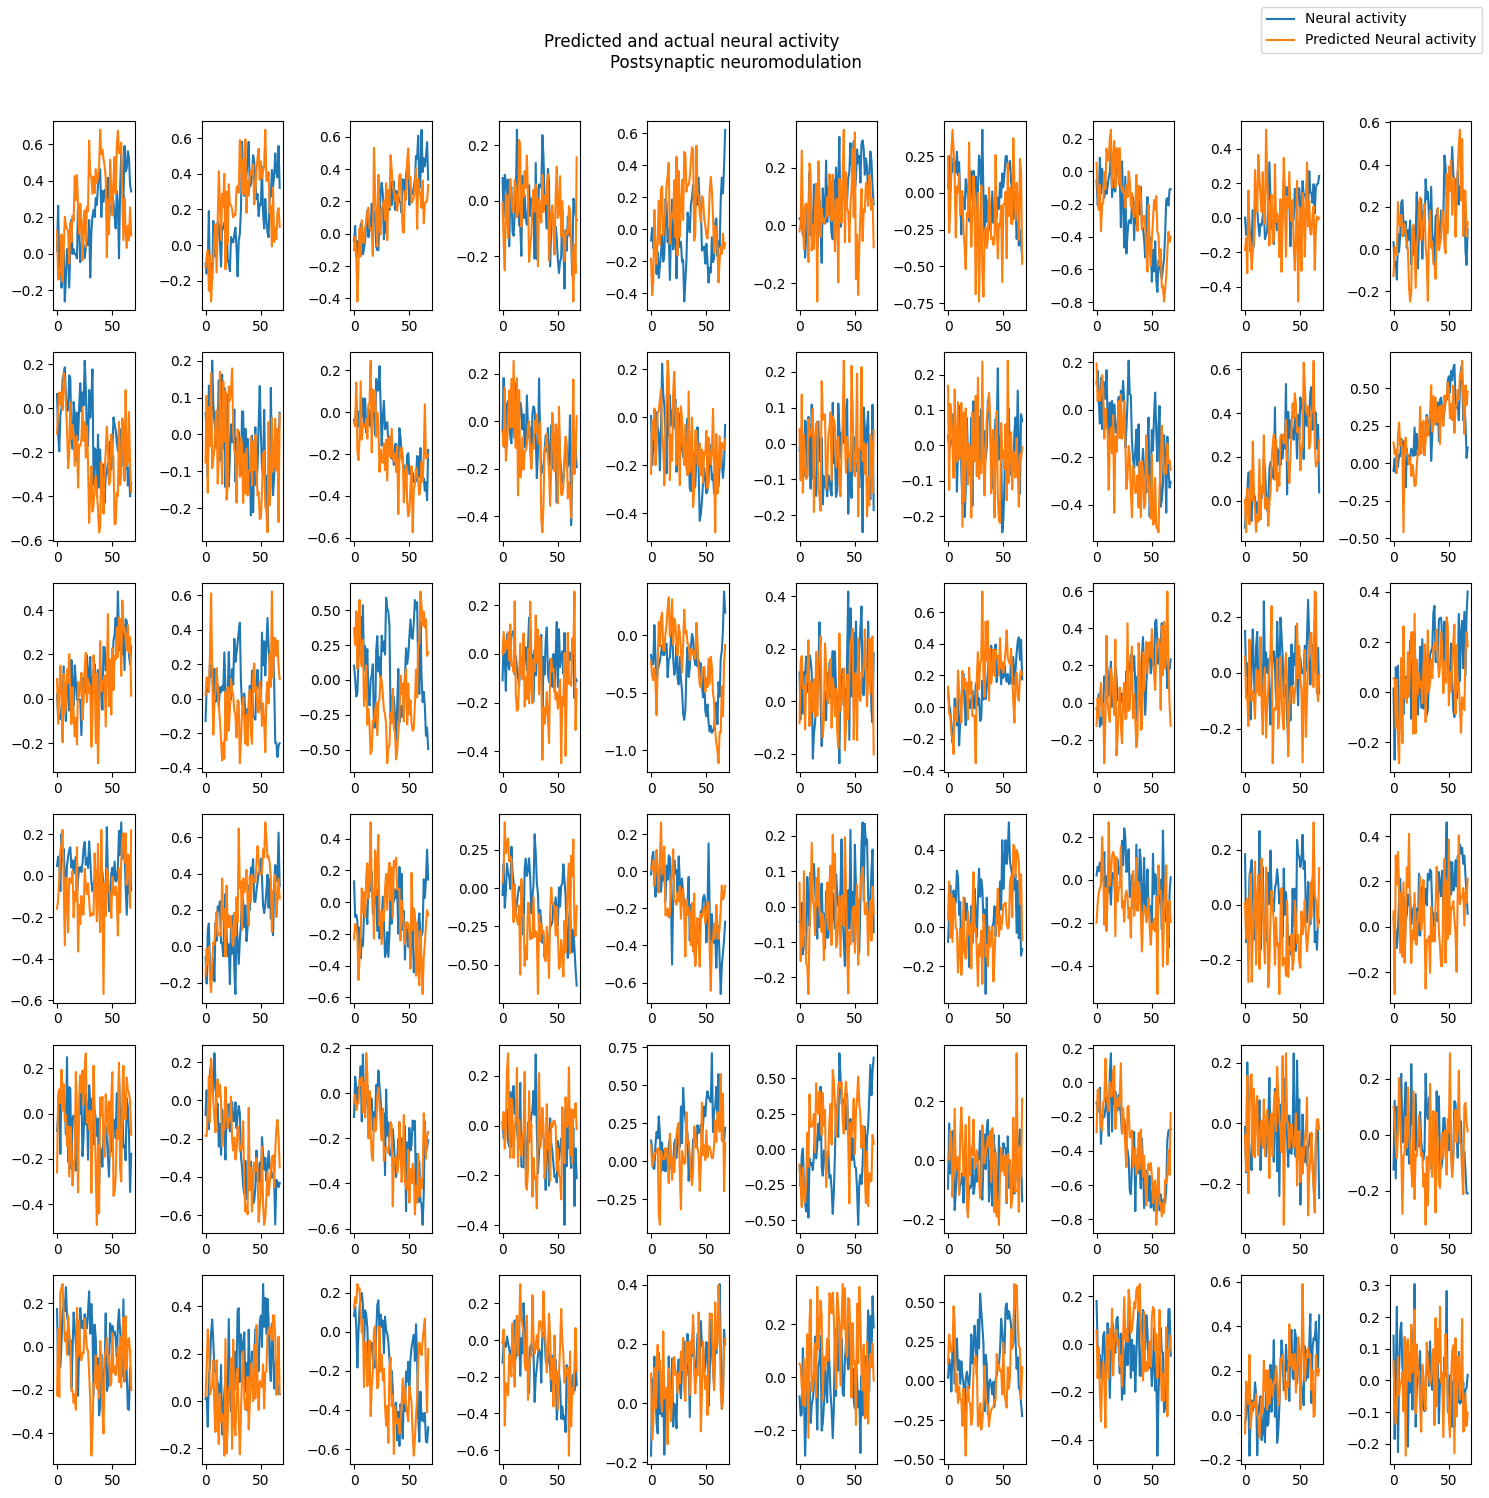

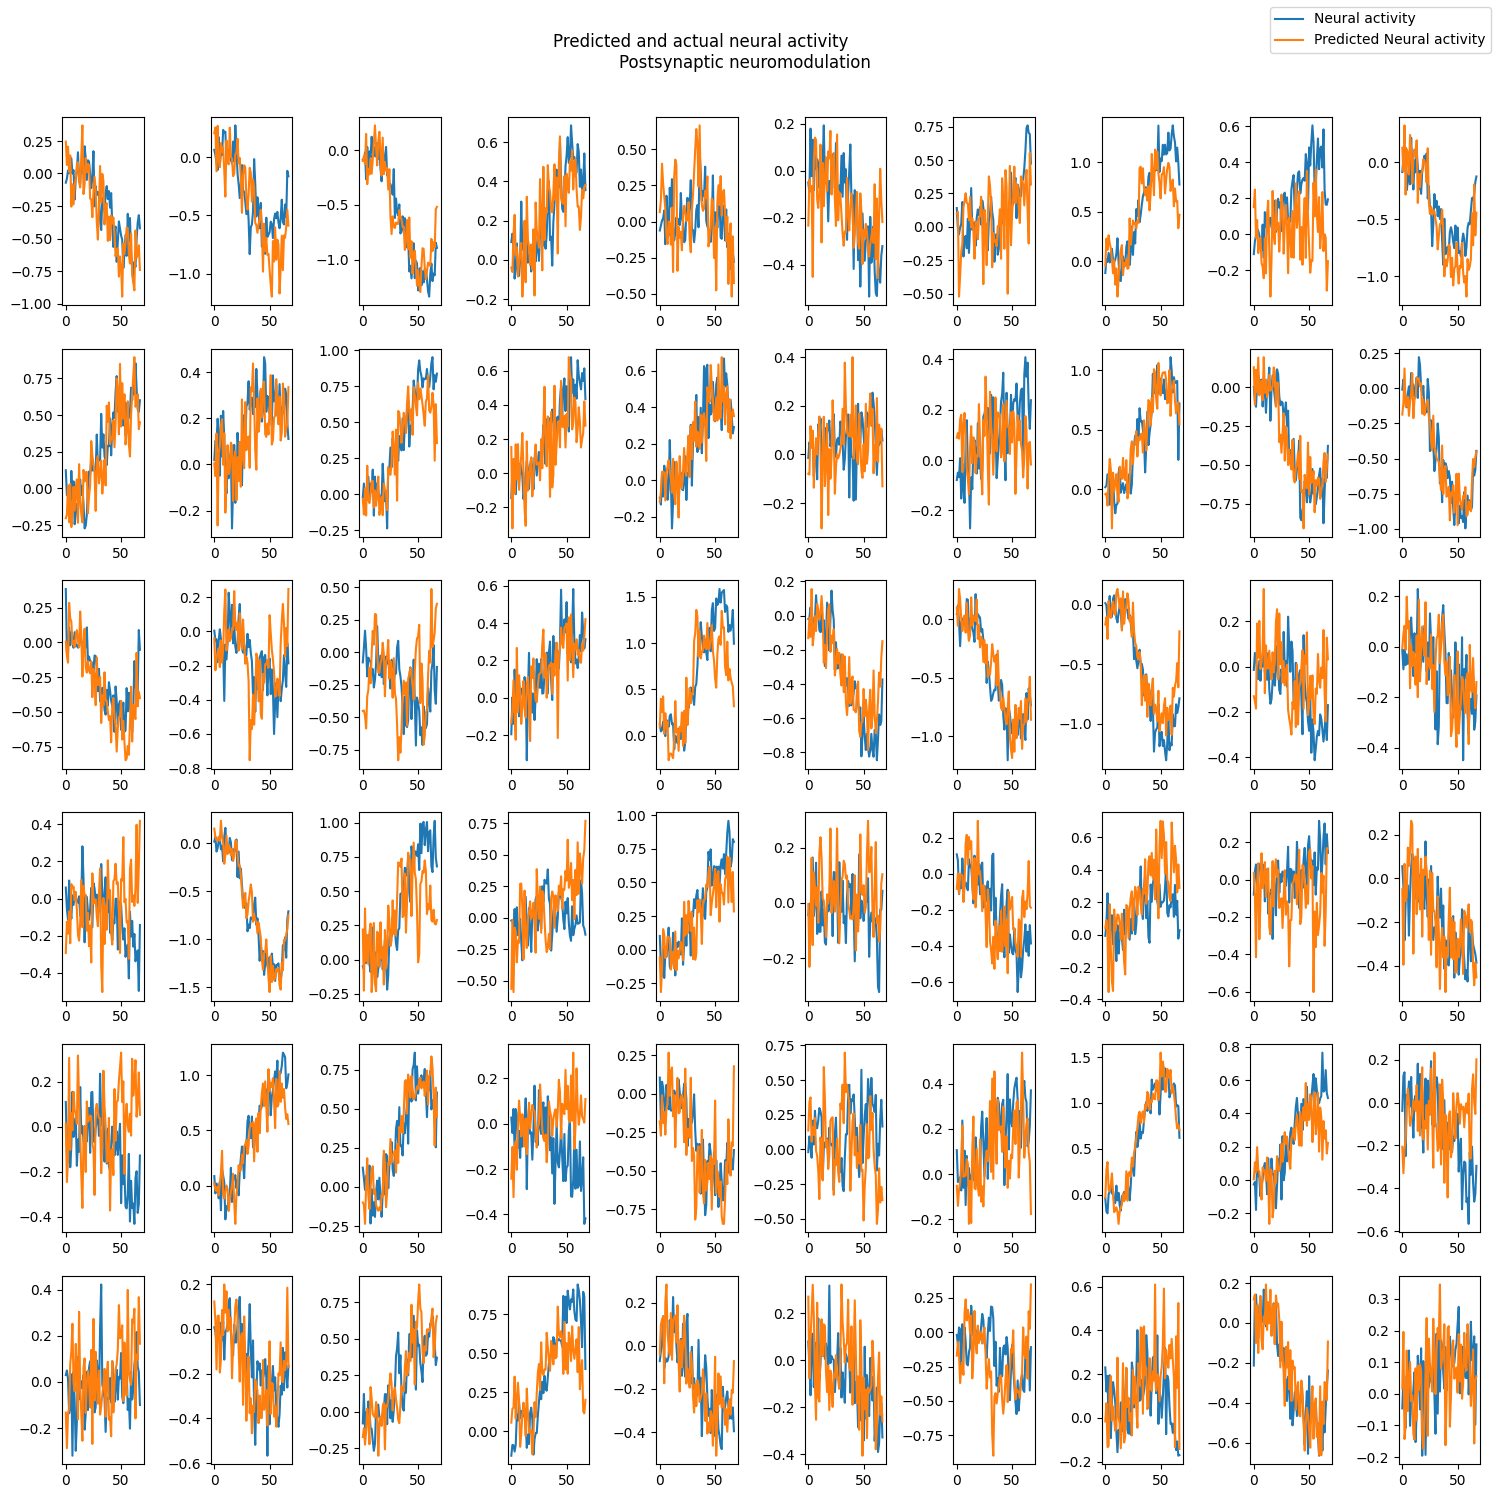

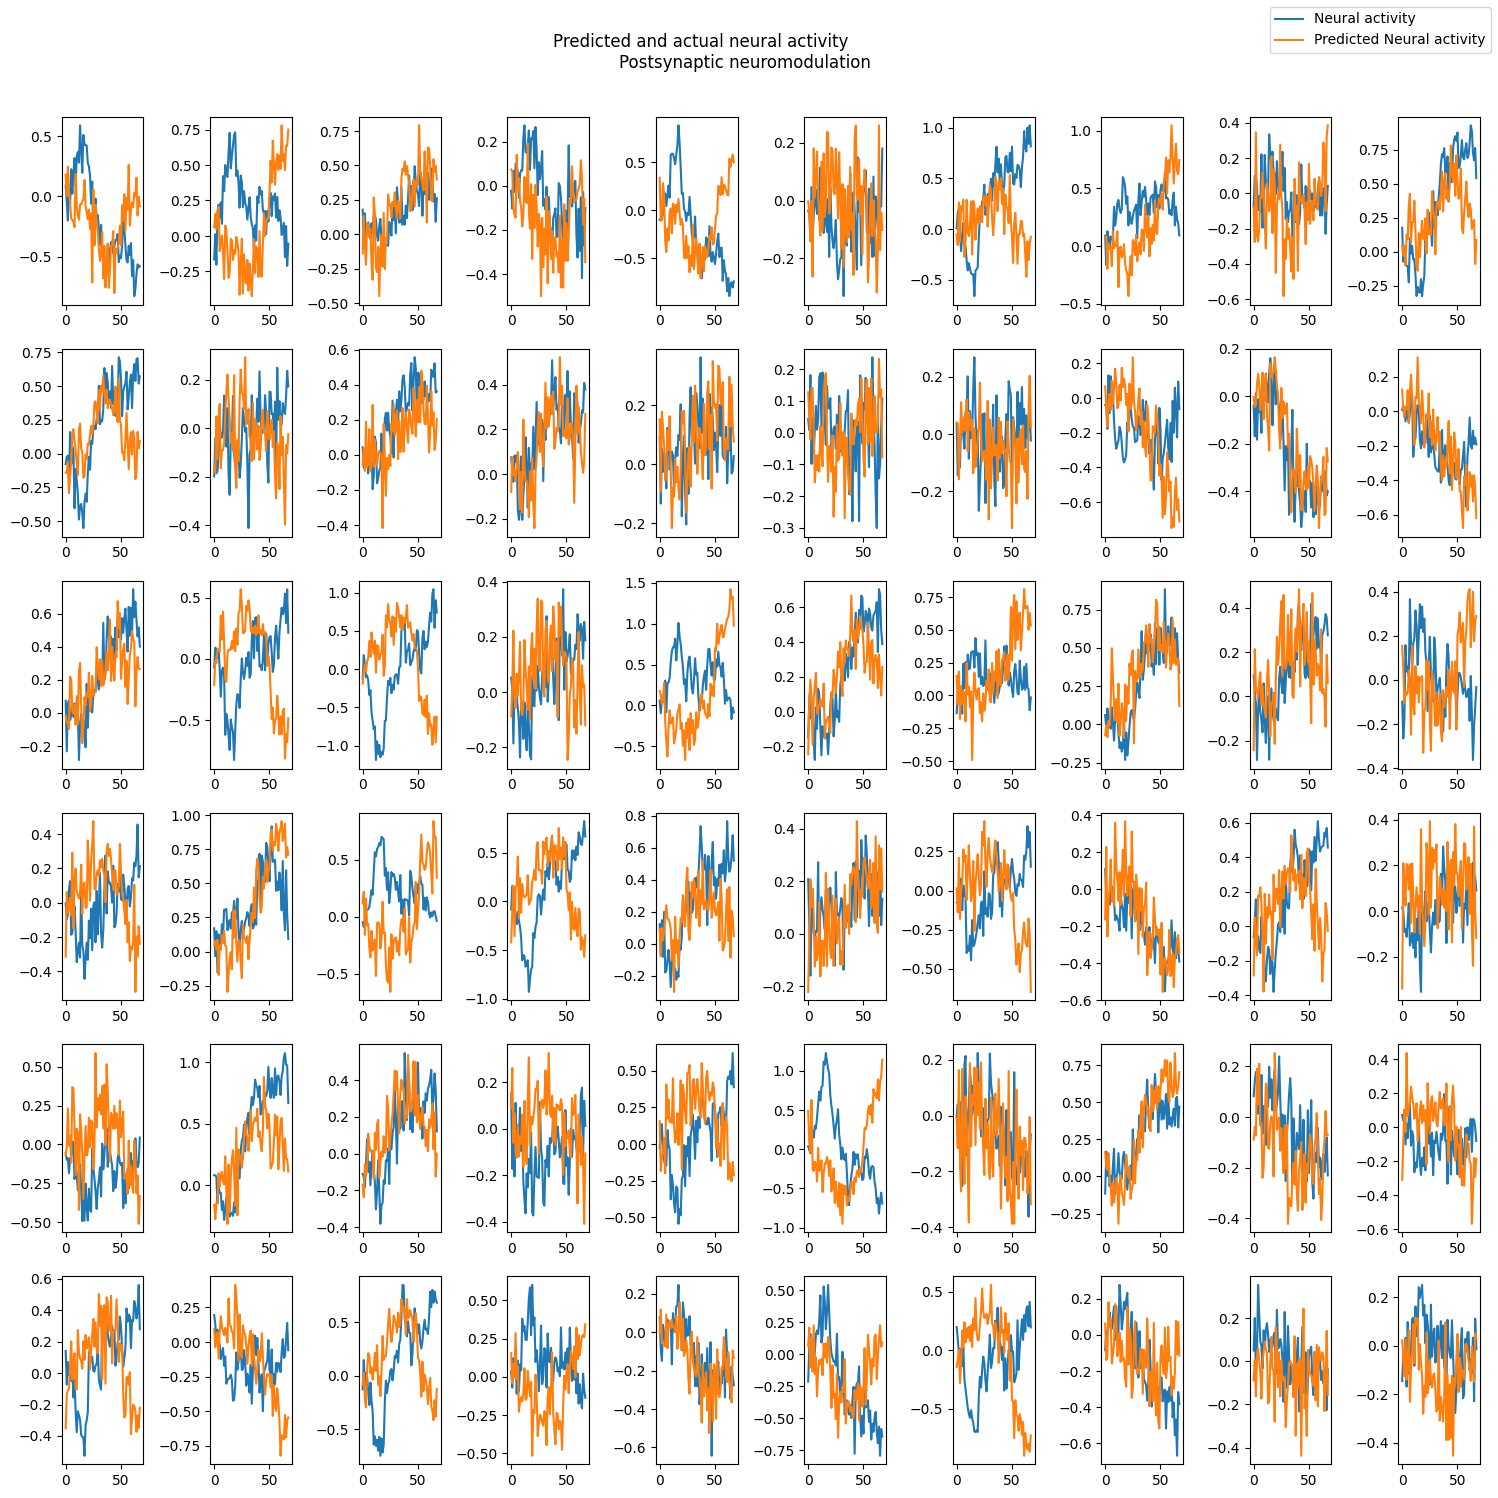

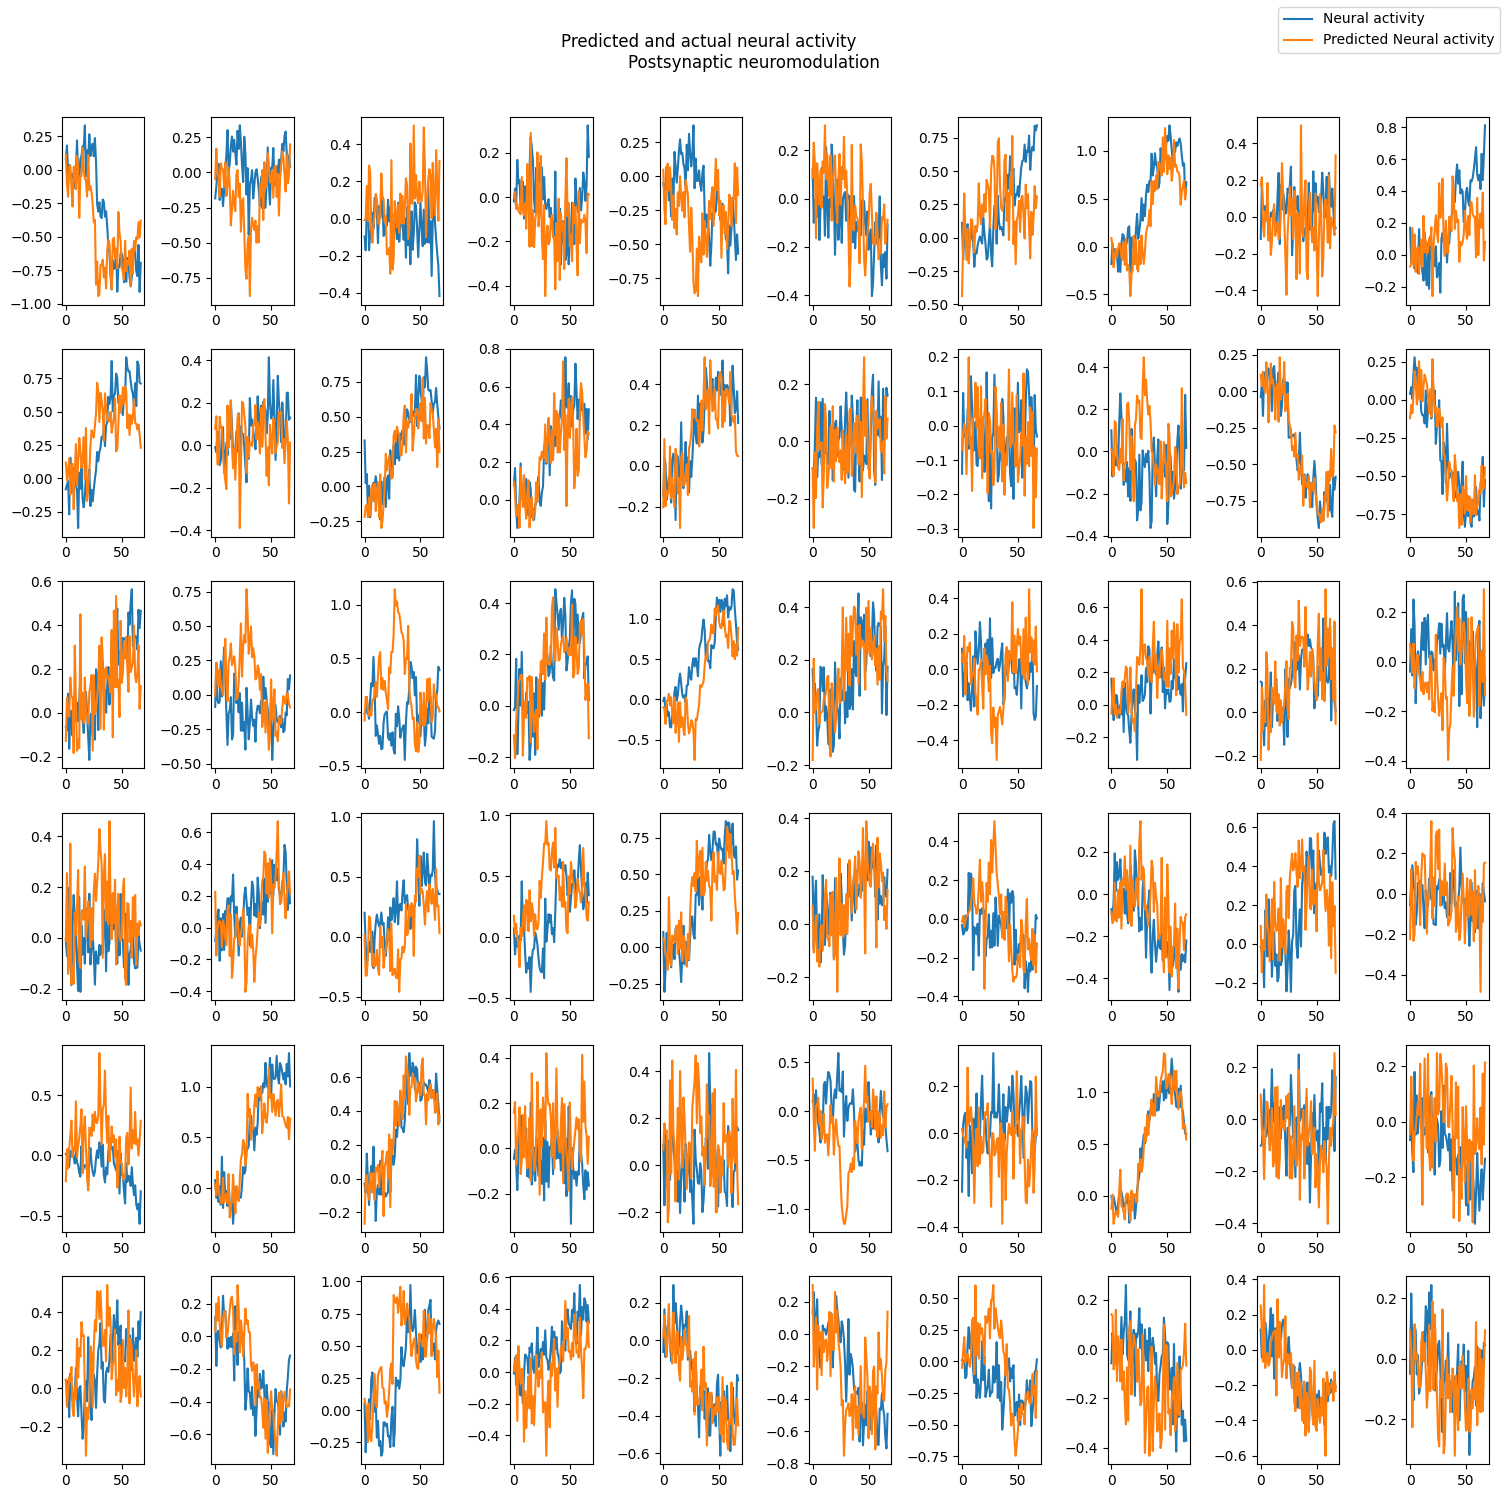

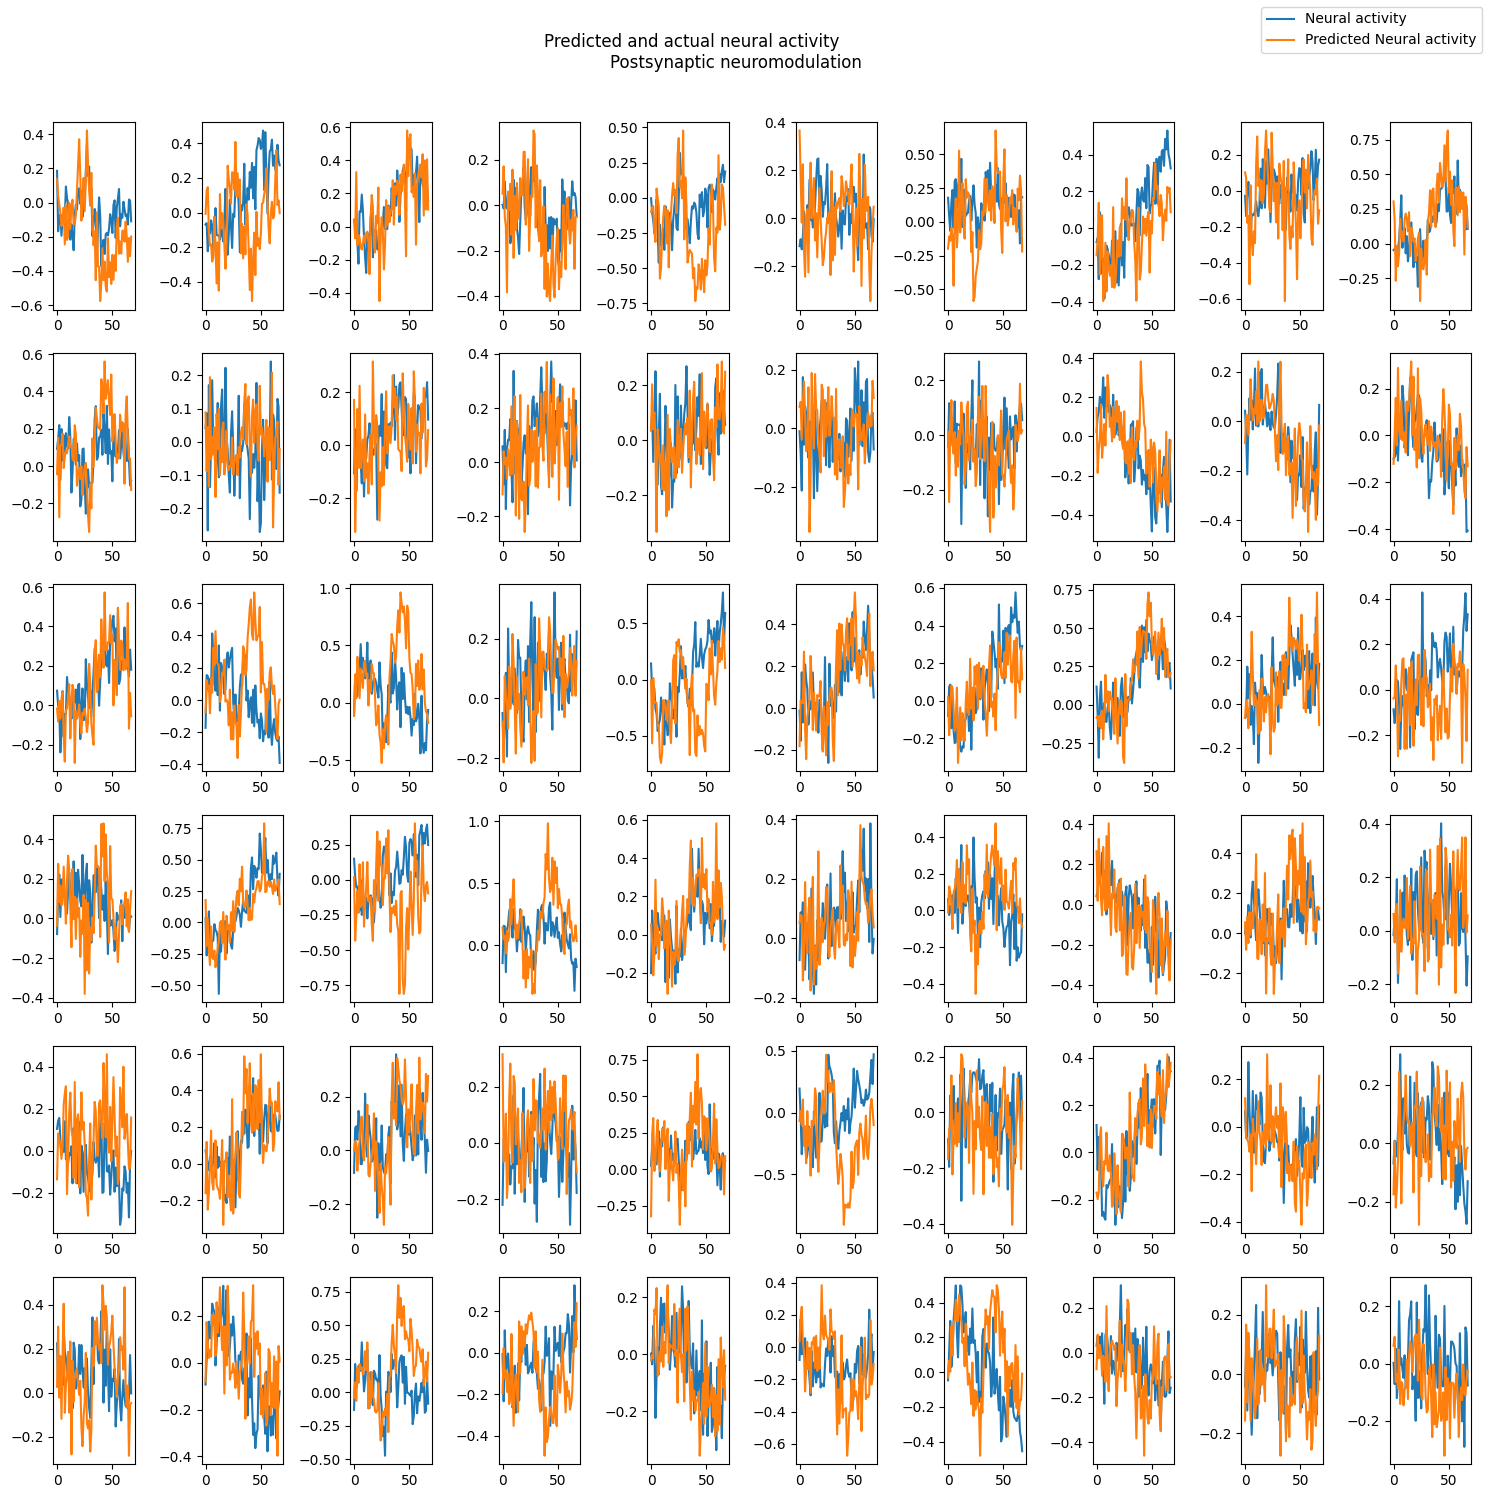

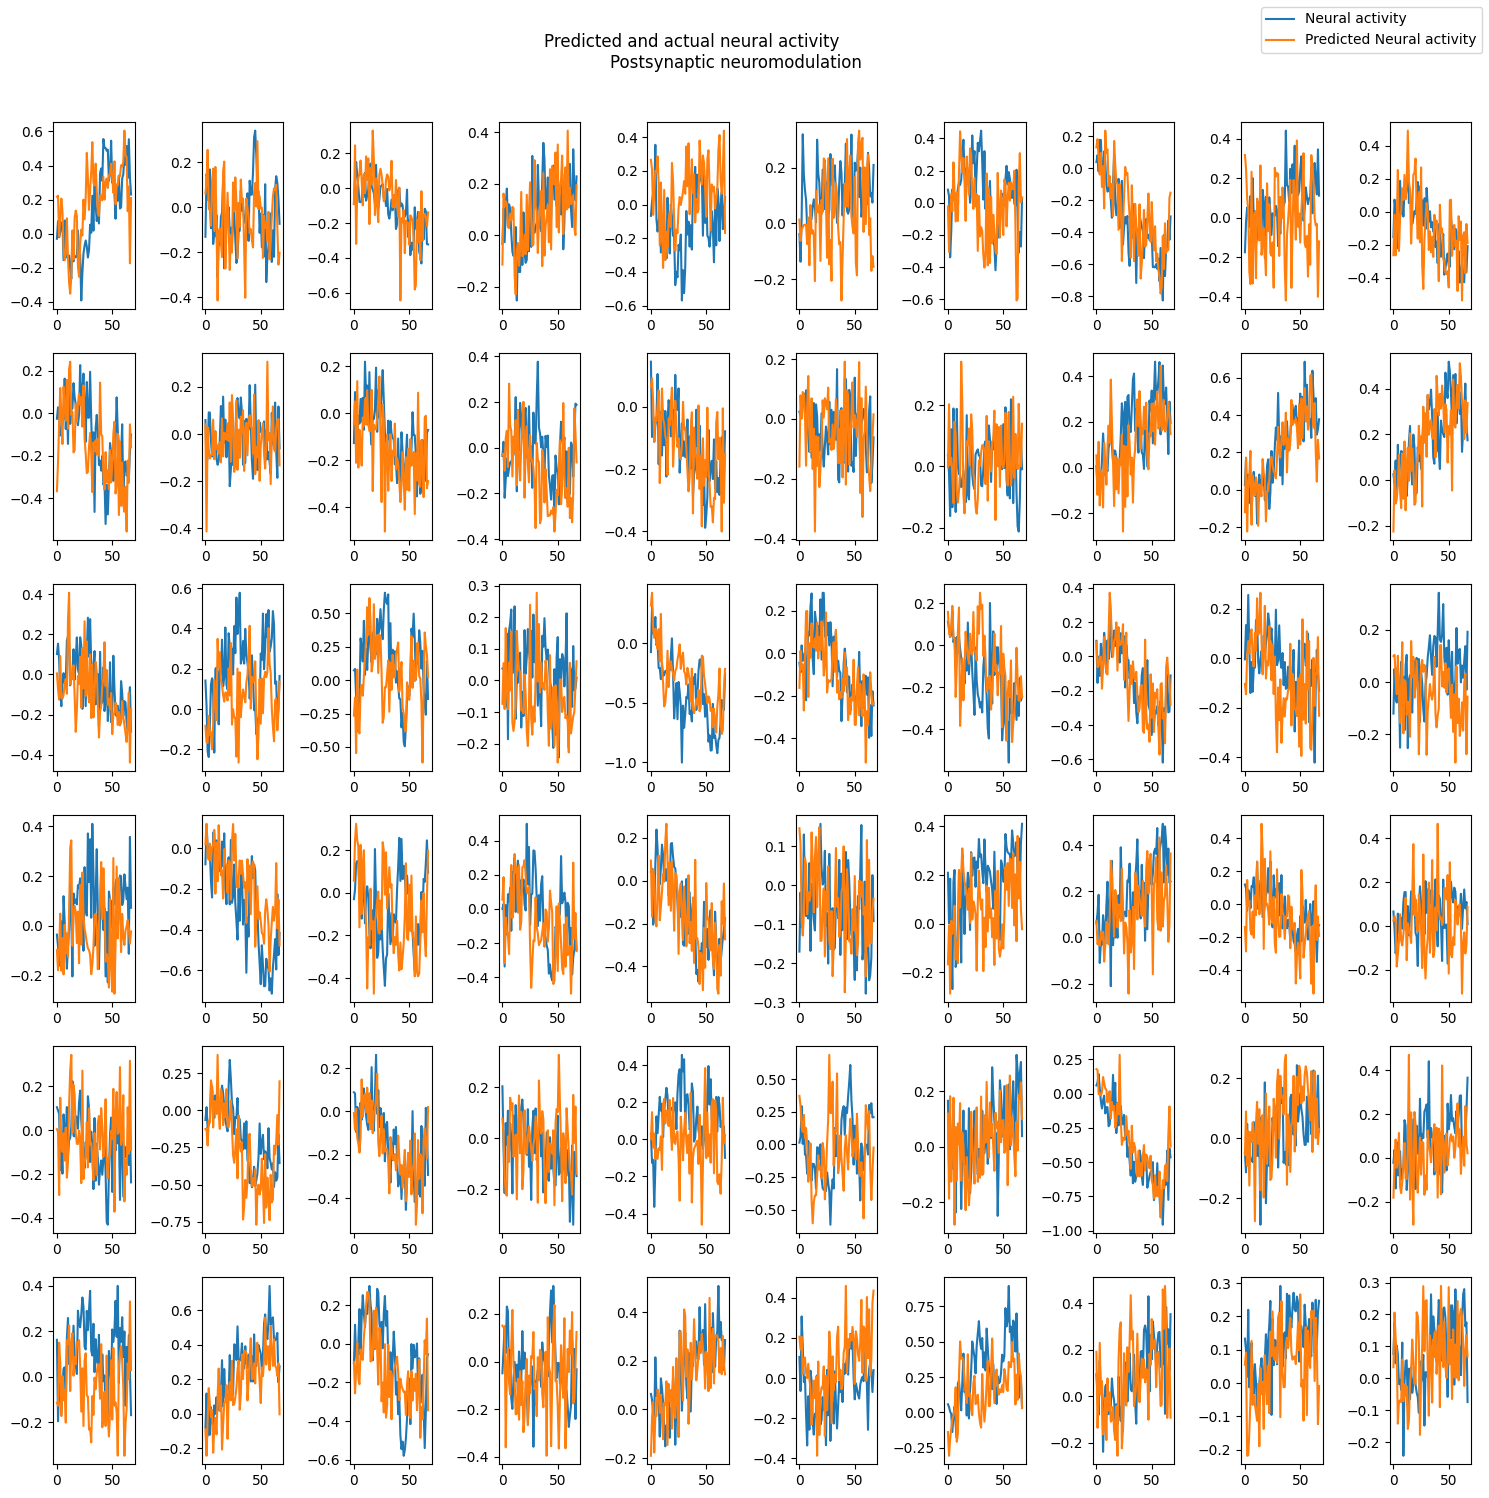

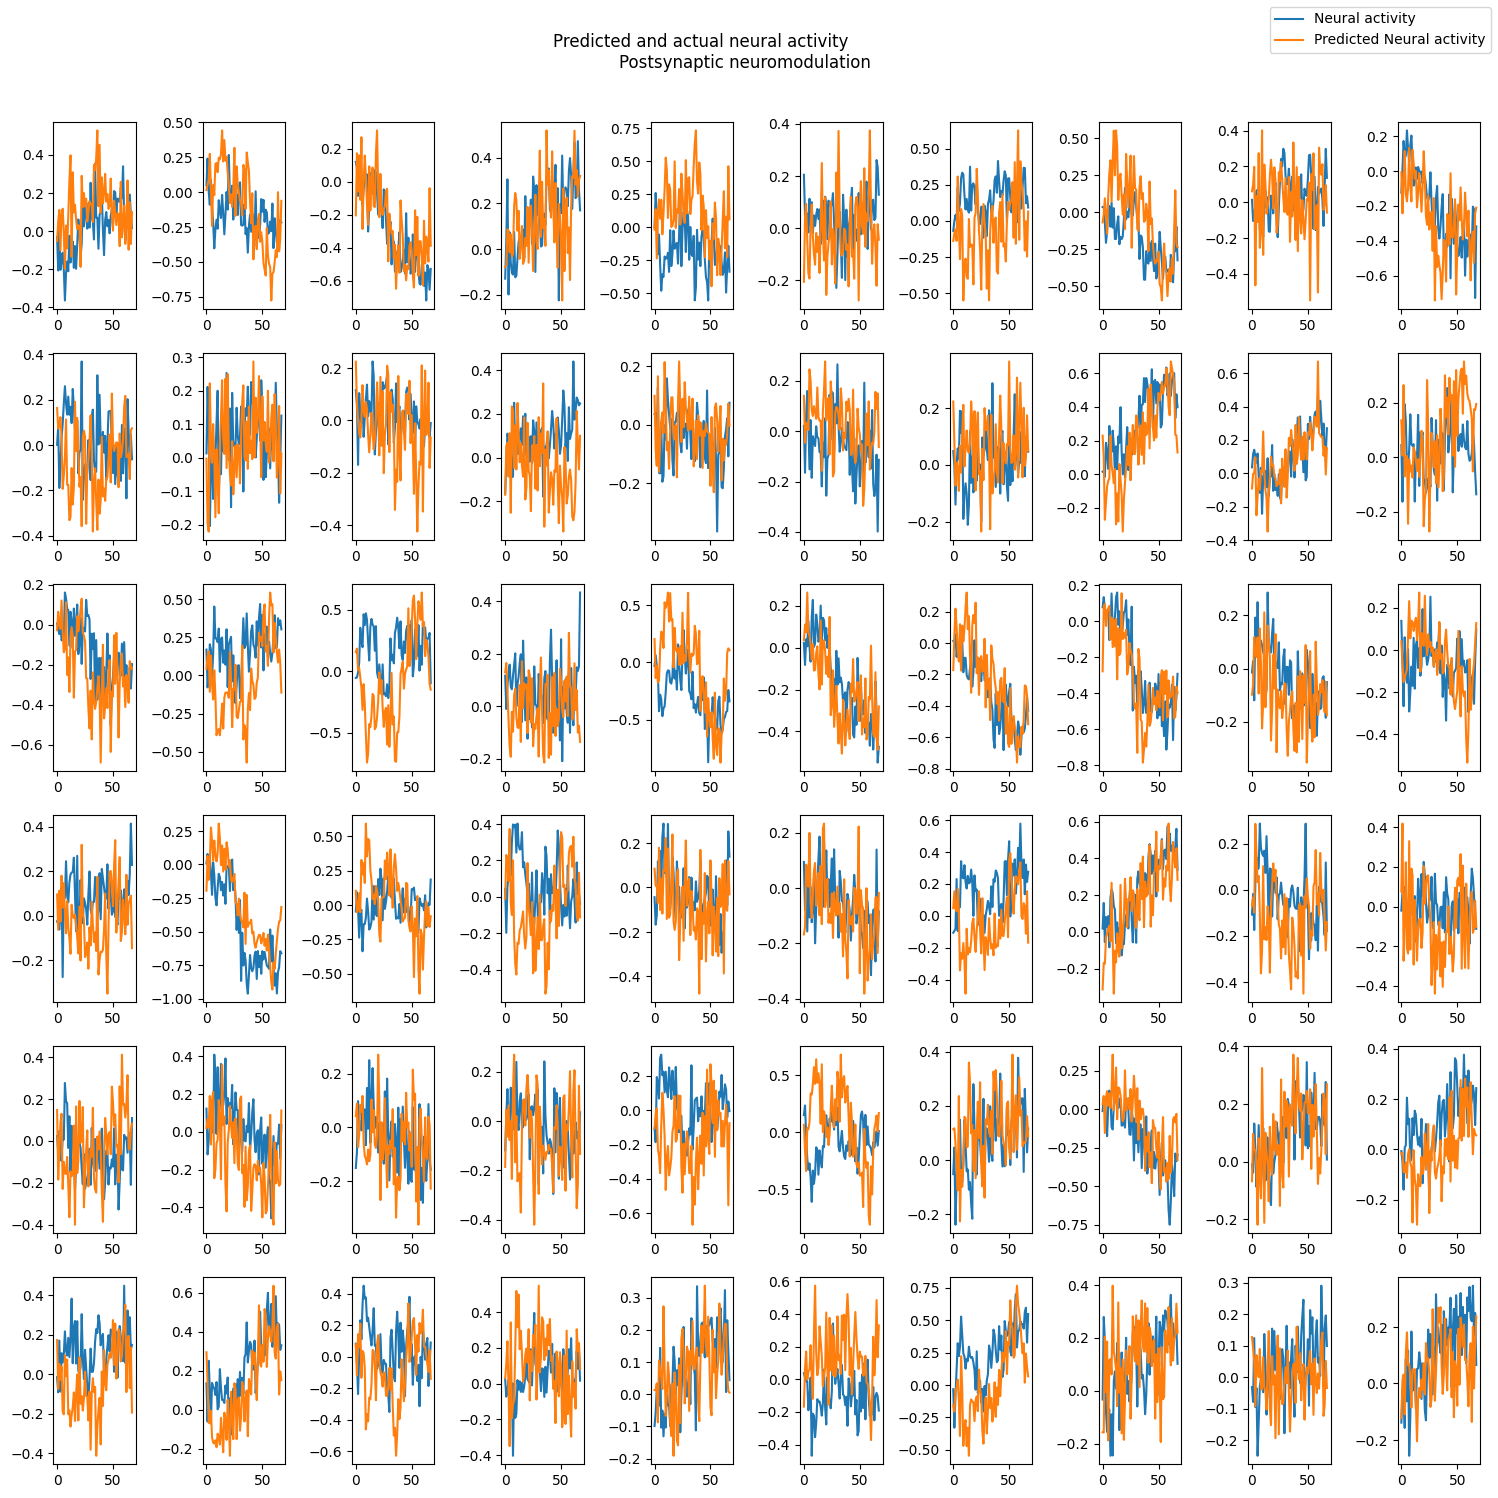

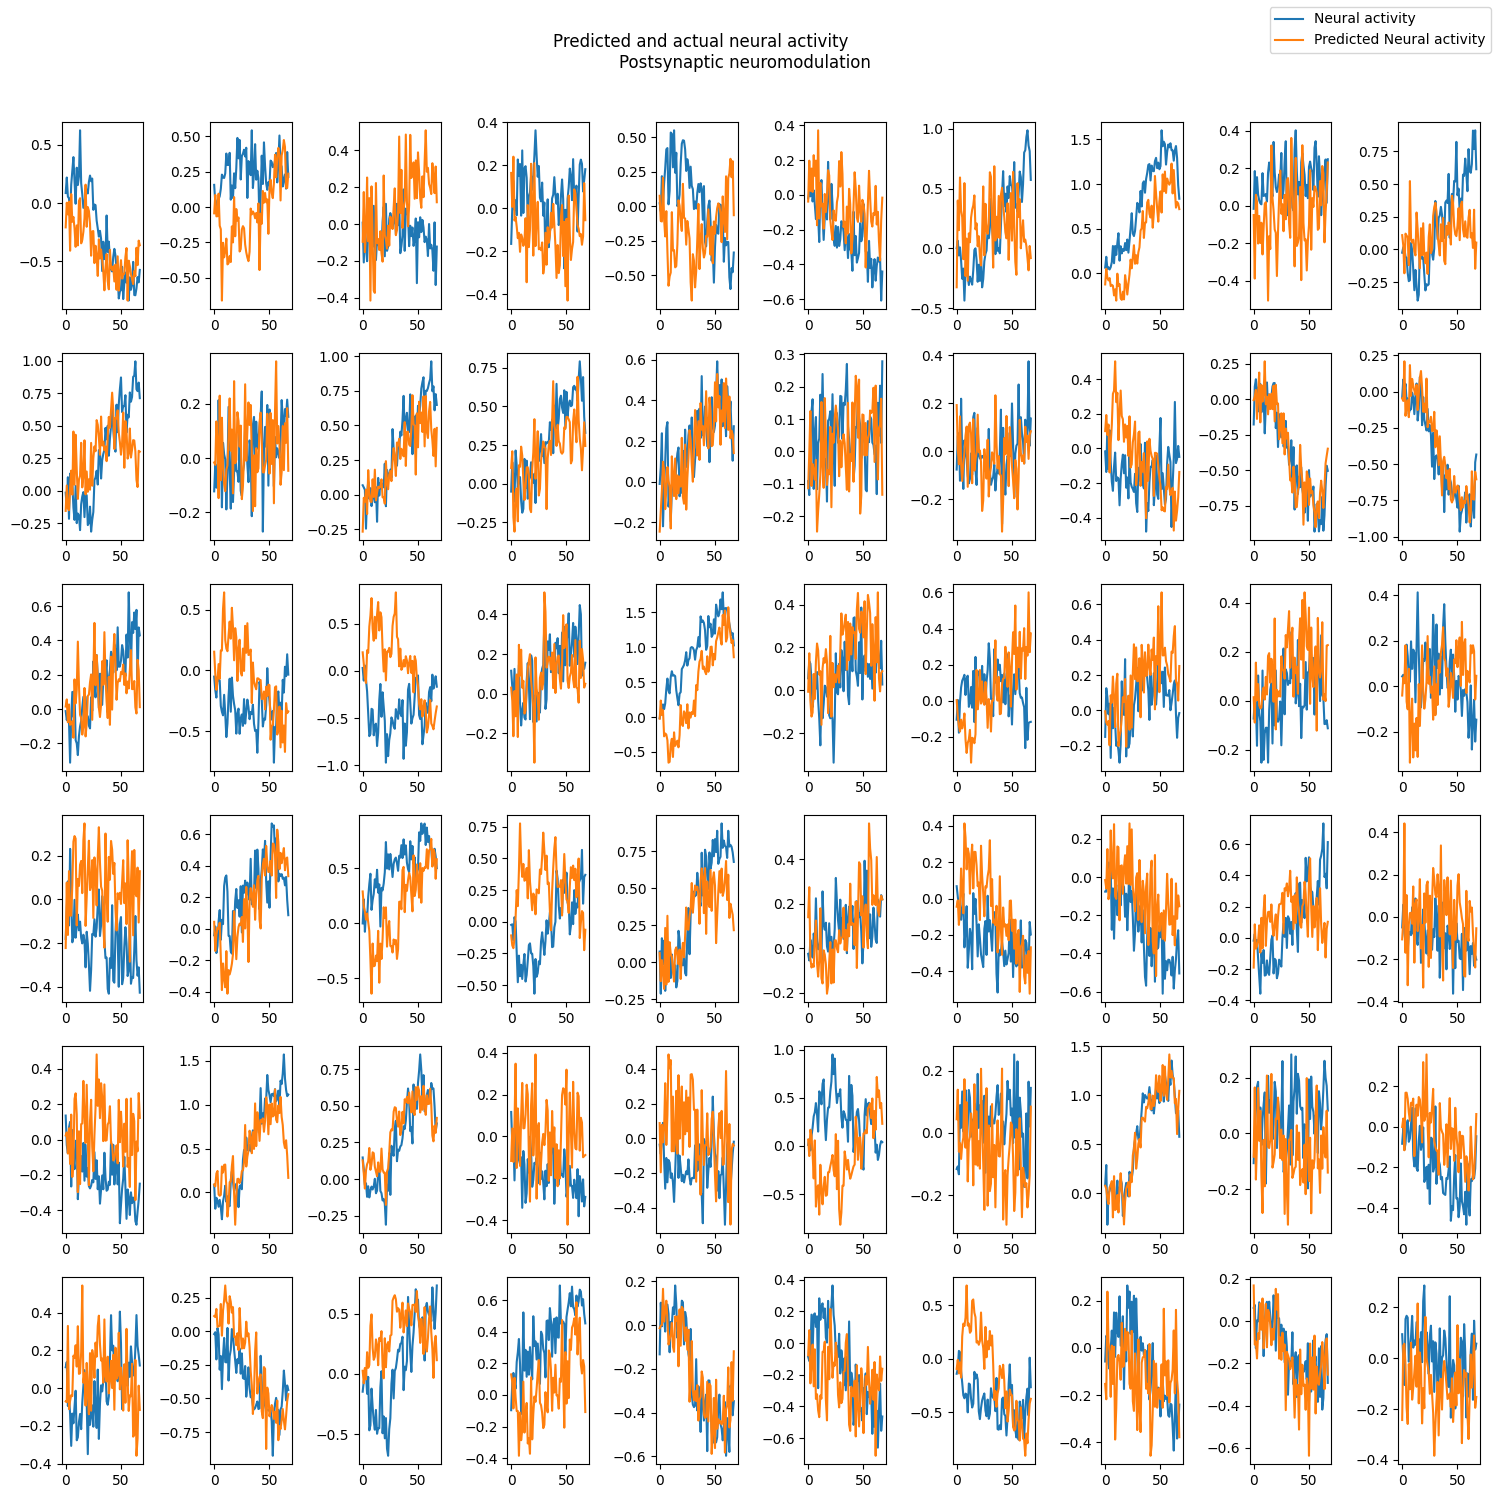

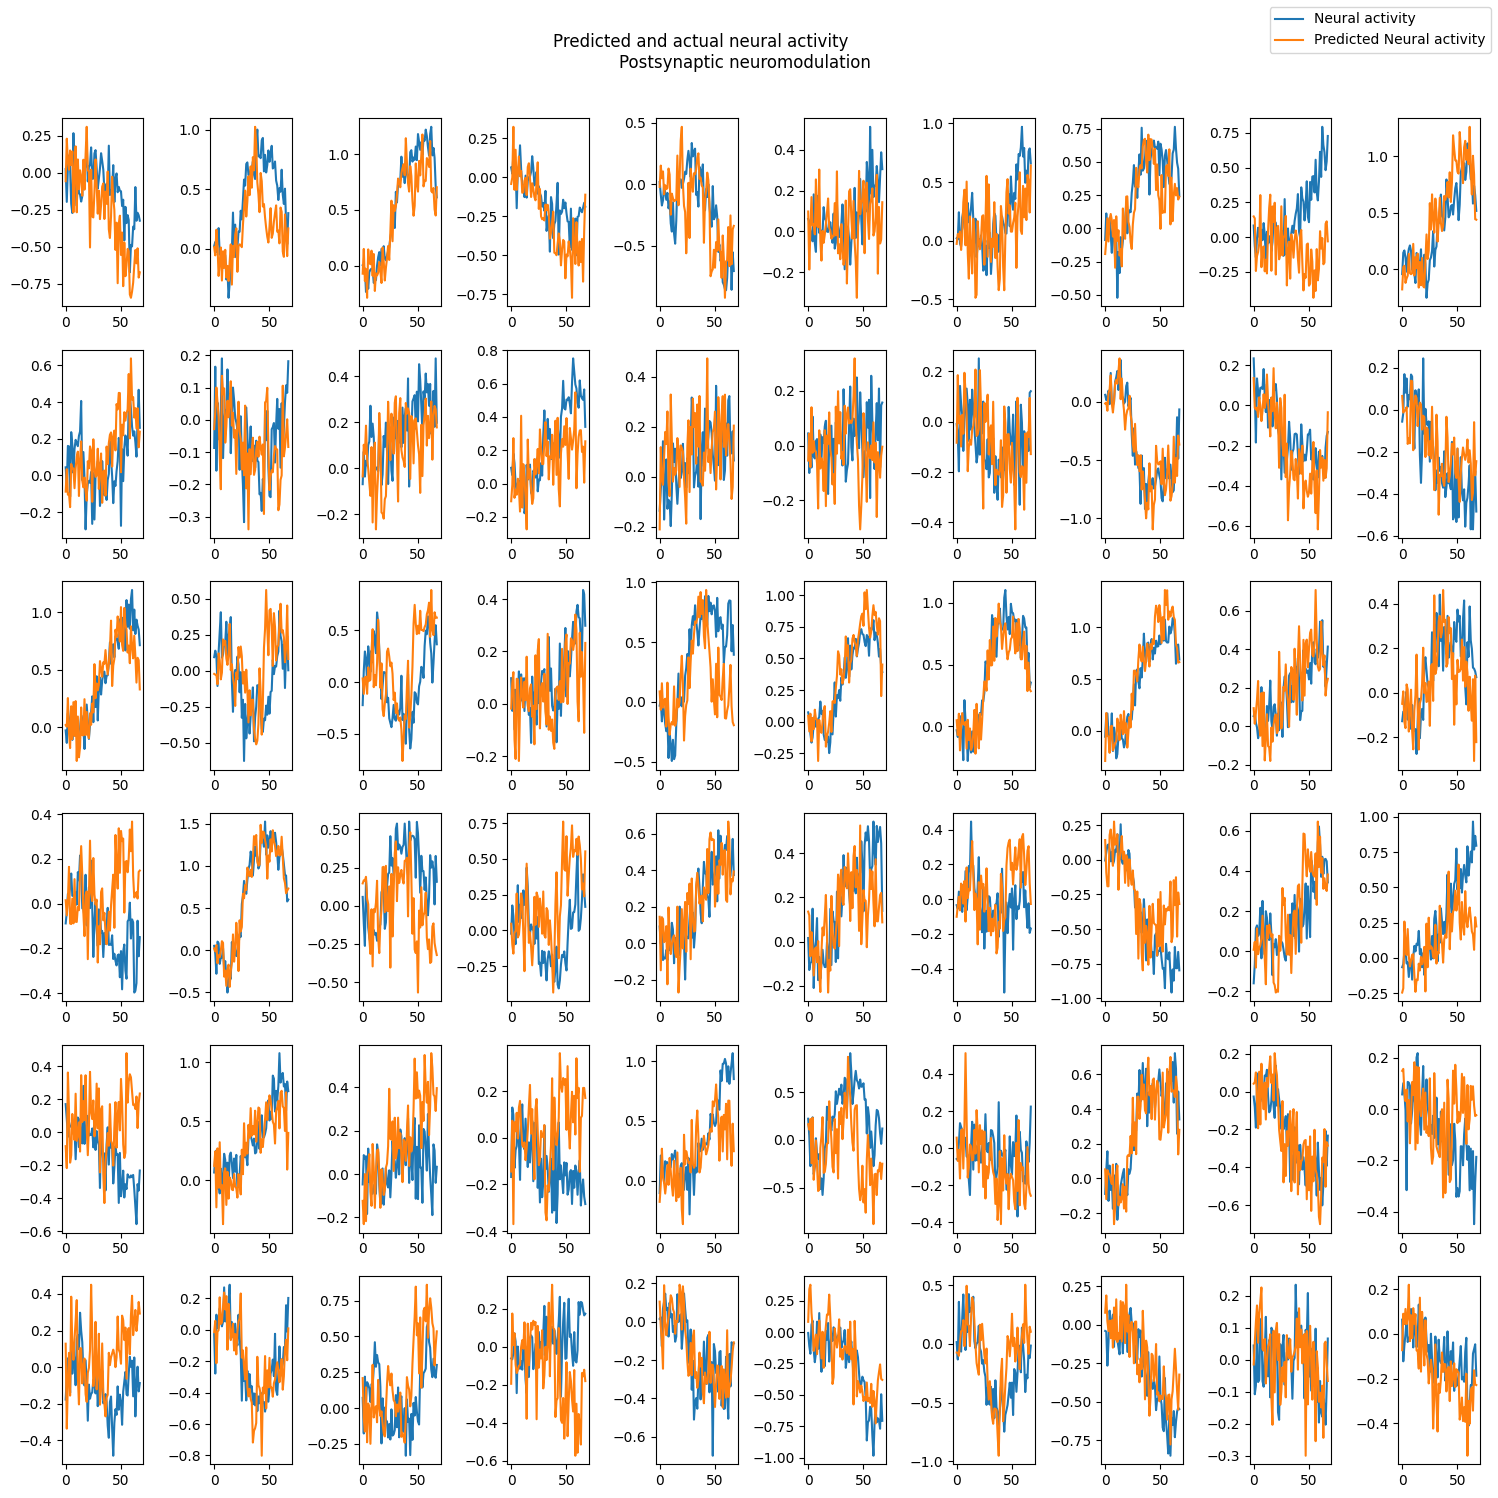

In [19]:
import matplotlib.pyplot as plt 
kl_div = []
for b in range(10):
    # compute the KL-Divergence 
    kl_div_b = compute_KL_divergence(X_pred[b].unsqueeze(0), task.data[b])
    kl_div.append(kl_div_b) 
    # plot population activity 
    fig, ax = plt.subplots(6, 10, figsize=(15, 15))
    idx_i, idx_j = 0, 0
    for i in range(task_params["n_neurons"]):
        ax[idx_i, idx_j].plot(task.data[b, :, i], label=f'Neural activity')
        ax[idx_i, idx_j].plot(X_pred[b, :, i], label=f'Predicted Neural activity')
        idx_j += 1
        if idx_j >= 10: 
            idx_i, idx_j = idx_i + 1, 0
        
    fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')
    fig.suptitle(f"Predicted and actual neural activity\
                 \nPostsynaptic neuromodulation")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    # fig.savefig(f"{figures_dir}/mante postsynaptic rank 2/plot_{b}.png")
    # plt.show()
    
    

In [20]:
np.array(kl_div).mean()

0.34617884159088136

#### Compute $\mathbf{R}^2$ for each neuron across trials

In [21]:
import seaborn as sns
from scipy.stats import pearsonr
# compute pearson's r

pearson_r = np.zeros((task_params["n_neurons"], task.data.size(0)))
for i in range(task_params["n_neurons"]):
    for b in range(task.data.shape[0]):
        pearson_r[i][b] = pearsonr(task.data[b, :, i], X_pred[b, :, i])[0]

In [22]:
pearson_r.mean()

0.3121180556749218

Text(0.5, 1.0, 'Pearson $R$ heatmap')

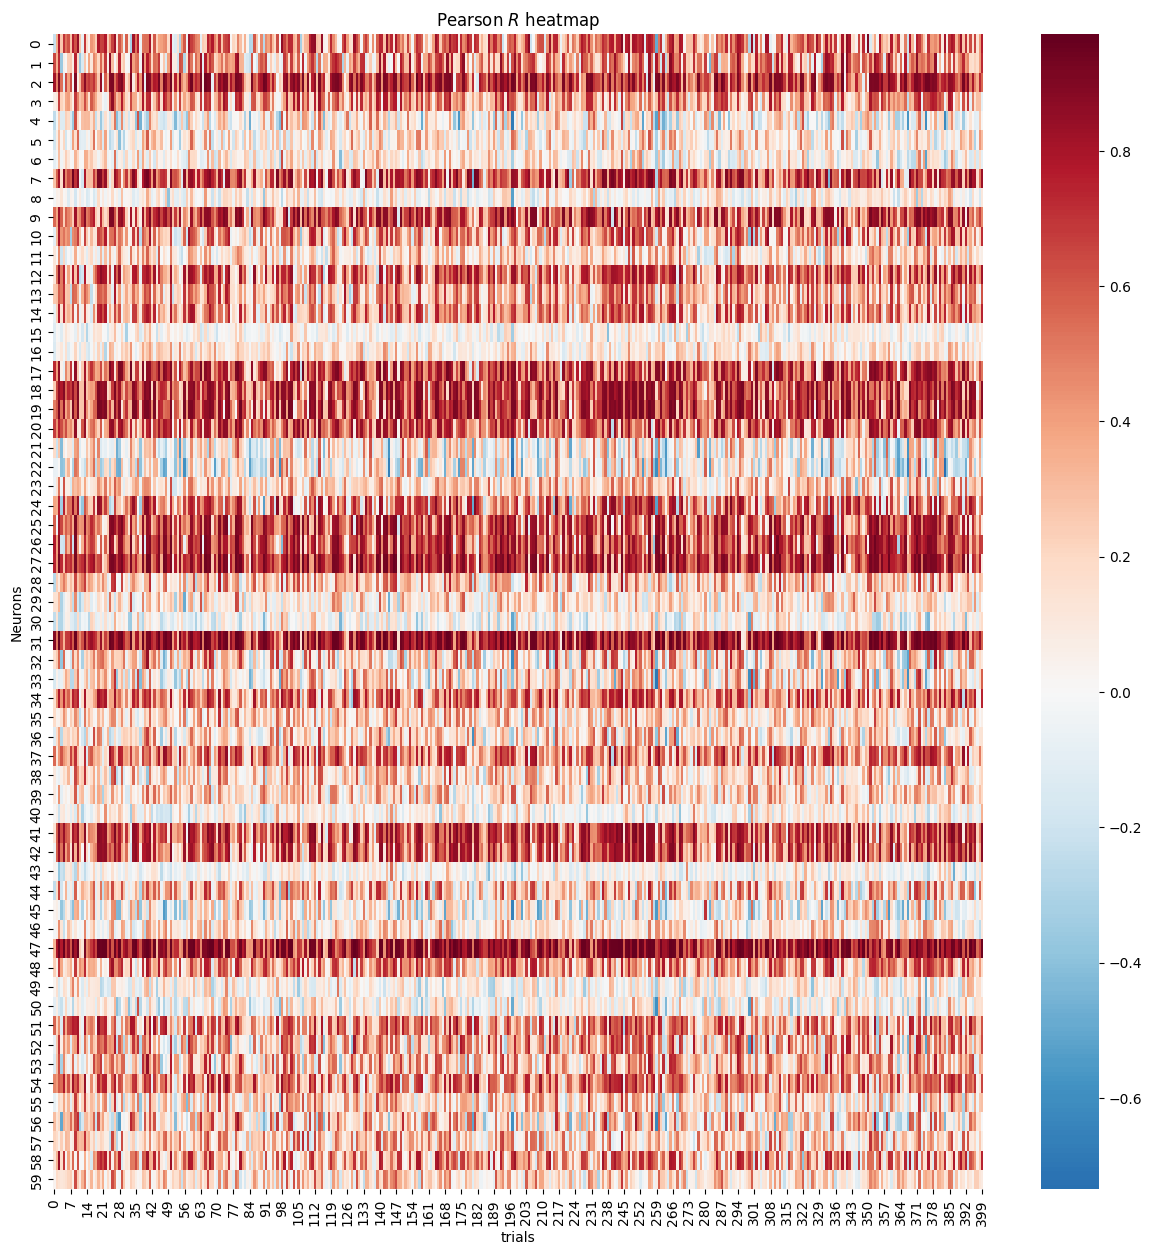

In [23]:
plt.figure(figsize=(15, 15))
# r2_arr[r2_arr < -1] = -1
sns.heatmap(pearson_r[:, :], annot=False, cmap='RdBu_r', center=0, cbar=True)
# x_ticks = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# x_labels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# plt.xticks(x_ticks, x_labels)
plt.ylabel('Neurons')
plt.xlabel('trials')
plt.title(f'Pearson $R$ heatmap')
# plt.savefig('rank_scaling_pearson_r.png')

### Student activity projected on student latent space

Text(0.5, 1.0, 'Student activity projected on student latent space')

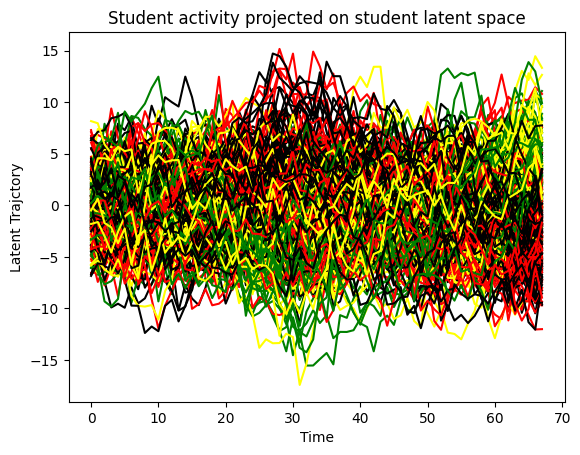

In [24]:
z_stud_stud = X_pred@model.rnn.transition.m
# I = model.rnn.transition.Wu.detach().numpy()
for b in range(z_stud_stud.shape[0]):
    trial = z_stud_stud[b].detach().cpu().numpy()
    if task.s[b, :, 0].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='r')
    elif task.s[b, :, 0].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='g')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='black')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='yellow')
plt.xlabel('Time')
plt.ylabel('Latent Trajctory')
plt.title('Student activity projected on student latent space')

### Teacher activity projected on teacher latent space

Text(0.5, 1.0, 'Teacher activity projected on teacher latent space')

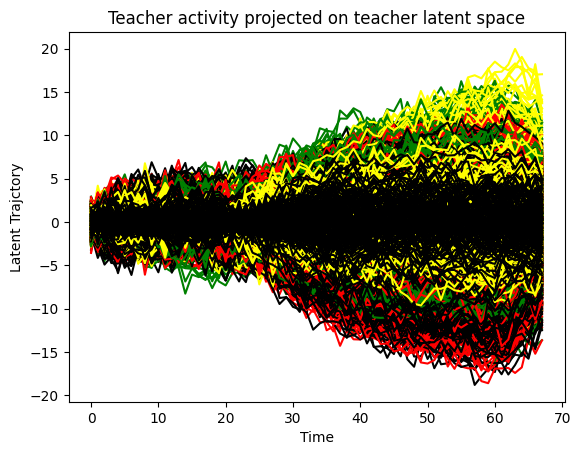

In [26]:
z_teach_teach = task.data @ rnn_mante.rnn.m
for b in range(z_teach_teach.shape[0]):
    trial = z_teach_teach[b].detach().cpu().numpy()
    if task.s[b, :, 0].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='r')
    elif task.s[b, :, 0].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='g')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='black')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='yellow')
plt.xlabel('Time')
plt.ylabel('Latent Trajctory')
plt.title('Teacher activity projected on teacher latent space')

### Student activity projected on teacher latent space

Text(0.5, 1.0, 'Student activity projected on teacher latent space')

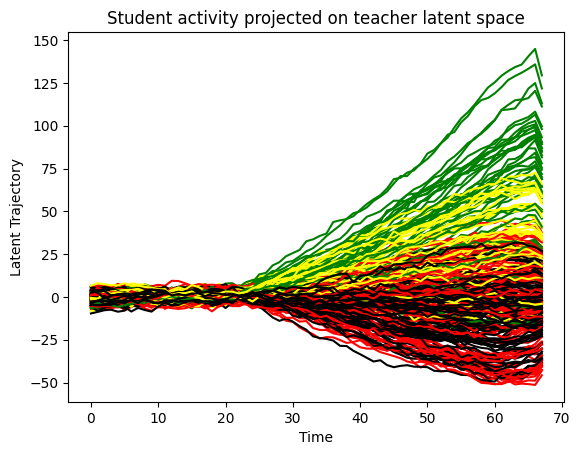

In [19]:
z_stud_teach = X_pred @ rnn_mante.rnn.m
for b in range(z_stud_teach.shape[0]):
    trial = z_stud_teach[b].detach().cpu().numpy()
    if task.s[b, :, 0].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='r', label='condition 1')
    elif task.s[b, :, 0].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='g', label='condition 2')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='black', label='condition 3')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='yellow', label='condition 4')
plt.xlabel('Time')
plt.ylabel('Latent Trajectory')
plt.title('Student activity projected on teacher latent space')

### Teacher activity projected on student latent space

Text(0.5, 1.0, 'Teacher activity projected on student latent space')

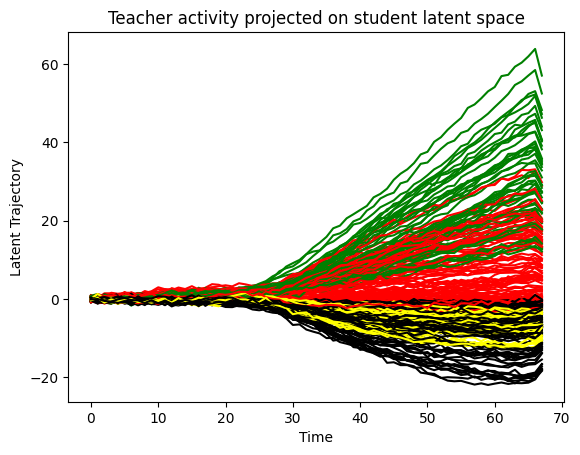

In [20]:
z_teach_stud = task.data @ model.rnn.transition.m
for b in range(z_teach_stud.shape[0]):
    trial = z_teach_stud[b].detach().cpu().numpy()
    if task.s[b, :, 0].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='r', label='condition 1')
    elif task.s[b, :, 0].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='g', label='condition 2')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='black', label='condition 3')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='yellow', label='condition 4')
plt.xlabel('Time')
plt.ylabel('Latent Trajectory')
plt.title('Teacher activity projected on student latent space')

Text(0.5, 1.0, 'Recovering neuromodulation weights')

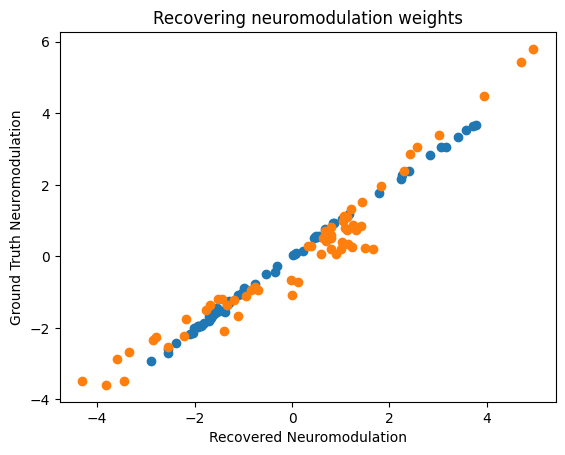

In [21]:
# w_inp = np.load(''.join([data_dir, 'teacher_winp.npy']))
plt.scatter(model.rnn.transition.Wu[:, 0].detach().cpu().numpy(), rnn_mante.rnn.w_inp[0, :].detach().numpy())
plt.scatter(model.rnn.transition.Wu[:, 1].detach().cpu().numpy(), rnn_mante.rnn.w_inp[1, :].detach().numpy())
plt.xlabel('Recovered Neuromodulation')
plt.ylabel('Ground Truth Neuromodulation')
plt.title('Recovering neuromodulation weights')

Text(0.5, 1.0, 'Recovering Input weights')

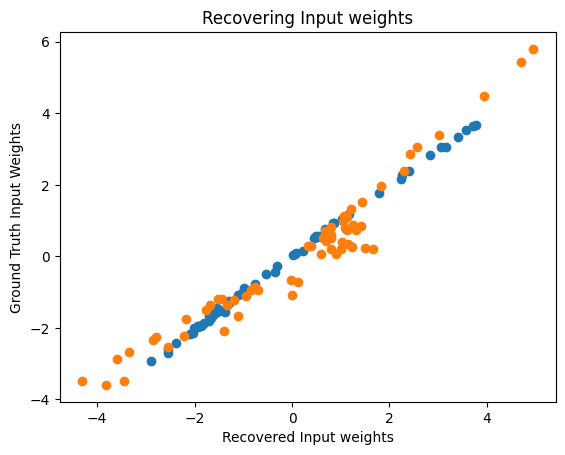

In [22]:
plt.scatter(model.rnn.transition.Wu[:, 0].detach().numpy(), rnn_mante.rnn.w_inp[0, :].detach())
plt.scatter(model.rnn.transition.Wu[:, 1].detach().numpy(), rnn_mante.rnn.w_inp[1, :].detach())
plt.xlabel('Recovered Input weights')
plt.ylabel('Ground Truth Input Weights')
plt.title('Recovering Input weights')

In [23]:
model.rnn.transition.A, rnn_mante.rnn.A

(Parameter containing:
 tensor([[1.9179, 1.5908]], requires_grad=True),
 Parameter containing:
 tensor([[ 5.5073, -4.8925]], requires_grad=True))